# Image Classification & Object Detection
## SVM | ANN (Feedforward + Backpropagation) | CNN | R-CNN

**Dataset:** CIFAR-10 (for SVM, ANN, CNN) | COCO subset via torchvision (for R-CNN)

---

## 📦 Step 1: Install & Import Libraries

In [1]:
!pip install -q torchvision torch scikit-learn matplotlib numpy opencv-python-headless

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, Subset
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 📂 Step 2: Load CIFAR-10 Dataset

In [3]:
# CIFAR-10 classes
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Transform for ANN/CNN (normalized tensors)
transform_nn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_nn)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_nn)

# Use a small subset for SVM (SVM is slow on 50k images)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f'Training samples : {len(train_dataset)}')
print(f'Testing  samples : {len(test_dataset)}')
print(f'Classes          : {CLASSES}')

100%|██████████| 170M/170M [00:06<00:00, 27.7MB/s]


Training samples : 50000
Testing  samples : 10000
Classes          : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


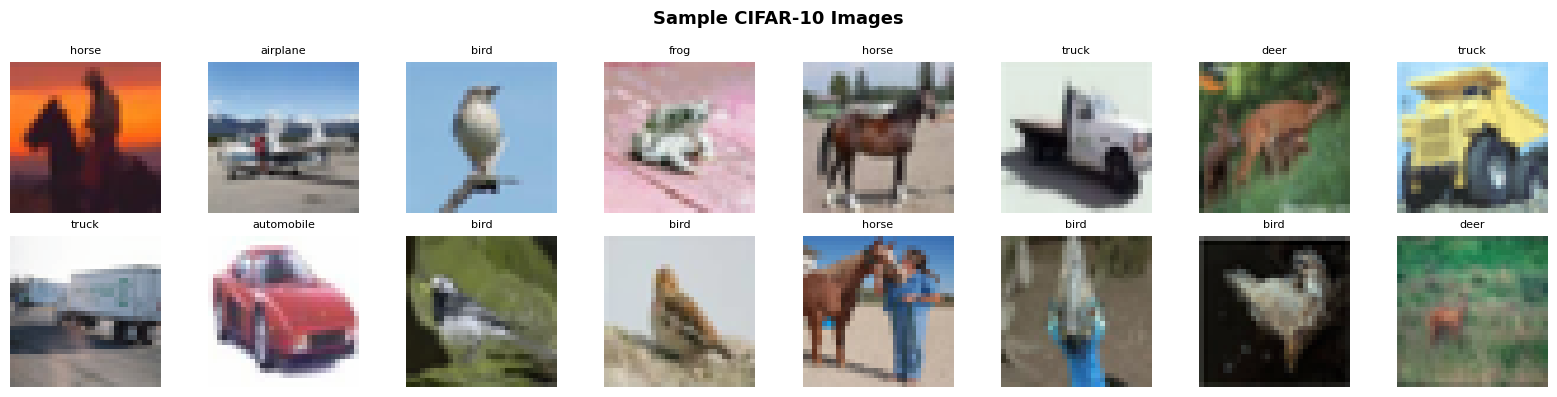

In [4]:
# Visualize sample images
def imshow(img_tensor, title=None):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    img = images[i].numpy().transpose((1, 2, 0))
    img = np.clip(np.array([0.2023,0.1994,0.2010]) * img + np.array([0.4914,0.4822,0.4465]), 0, 1)
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
plt.suptitle('Sample CIFAR-10 Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔷 PART 1A: Image Classification using SVM
Support Vector Machines classify images using HOG-like flattened pixel features + PCA dimensionality reduction.

In [5]:
# Extract flat pixel features for SVM (use 5000 train + 1000 test for speed)
def extract_features(dataset, n_samples):
    loader = DataLoader(Subset(dataset, range(n_samples)), batch_size=256, shuffle=False)
    X, y = [], []
    for imgs, lbls in loader:
        X.append(imgs.view(imgs.size(0), -1).numpy())
        y.append(lbls.numpy())
    return np.concatenate(X), np.concatenate(y)

print('Extracting features...')
X_train_svm, y_train_svm = extract_features(train_dataset, 5000)
X_test_svm,  y_test_svm  = extract_features(test_dataset,  1000)

# Normalize
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm  = scaler.transform(X_test_svm)

# PCA: reduce 3072-d to 150-d
pca = PCA(n_components=150, random_state=42)
X_train_svm = pca.fit_transform(X_train_svm)
X_test_svm  = pca.transform(X_test_svm)

print(f'Feature shape after PCA: {X_train_svm.shape}')
print(f'Explained variance     : {pca.explained_variance_ratio_.sum():.2%}')

Extracting features...
Feature shape after PCA: (5000, 150)
Explained variance     : 93.06%


In [6]:
# Train SVM with RBF kernel
print('Training SVM (RBF kernel)...')
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

svm_preds = svm_model.predict(X_test_svm)
svm_acc   = accuracy_score(y_test_svm, svm_preds)
print(f'\nSVM Test Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test_svm, svm_preds, target_names=CLASSES))

Training SVM (RBF kernel)...

SVM Test Accuracy: 0.4290 (42.90%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.45      0.49      0.47       103
  automobile       0.51      0.48      0.50        89
        bird       0.39      0.44      0.42       100
         cat       0.26      0.24      0.25       103
        deer       0.28      0.31      0.29        90
         dog       0.27      0.24      0.25        86
        frog       0.48      0.48      0.48       112
       horse       0.58      0.52      0.55       102
        ship       0.56      0.63      0.60       106
       truck       0.47      0.40      0.44       109

    accuracy                           0.43      1000
   macro avg       0.42      0.42      0.42      1000
weighted avg       0.43      0.43      0.43      1000



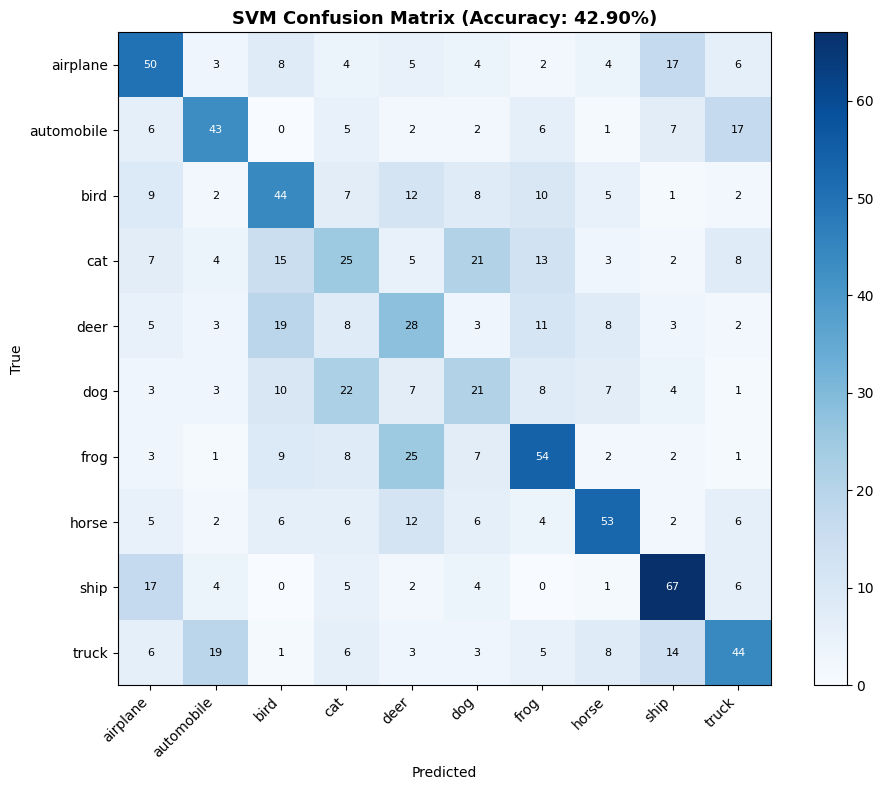

In [7]:
# SVM Confusion Matrix
cm = confusion_matrix(y_test_svm, svm_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'SVM Confusion Matrix (Accuracy: {svm_acc:.2%})', fontsize=13, fontweight='bold')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

---
## 🔷 PART 1B: Image Classification using ANN (Feedforward + Backpropagation)
A multi-layer perceptron trained with gradient descent and backpropagation.

In [8]:
class ANN(nn.Module):
    """Feedforward Artificial Neural Network with Backpropagation."""
    def __init__(self):
        super(ANN, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            # Input layer: 3x32x32 = 3072
            nn.Linear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Hidden layer 1
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Hidden layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Output layer
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

ann_model = ANN().to(device)
print('ANN Architecture:')
print(ann_model)
total_params = sum(p.numel() for p in ann_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ANN Architecture:
ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 3,809,034


In [9]:
# Training function
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, label='Model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()          # <-- Backpropagation
            optimizer.step()         # <-- Weight update
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(lbls).sum().item()
            total   += lbls.size(0)

        # ---- Evaluate ----
        model.eval()
        test_loss, t_correct, t_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                t_correct += predicted.eq(lbls).sum().item()
                t_total   += lbls.size(0)

        tr_loss = train_loss / len(train_loader)
        te_loss = test_loss  / len(test_loader)
        tr_acc  = correct    / total
        te_acc  = t_correct  / t_total

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        scheduler.step()
        print(f'[{label}] Epoch {epoch+1:02d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Test Loss: {te_loss:.4f} Acc: {te_acc:.4f}')

    return history

In [10]:
print('Training ANN (Feedforward + Backpropagation)...')
ann_history = train_model(ann_model, train_loader, test_loader, epochs=10, lr=0.001, label='ANN')

Training ANN (Feedforward + Backpropagation)...
[ANN] Epoch 01/10 | Train Loss: 1.6970 Acc: 0.3895 | Test Loss: 1.4894 Acc: 0.4730
[ANN] Epoch 02/10 | Train Loss: 1.5224 Acc: 0.4551 | Test Loss: 1.4273 Acc: 0.4951
[ANN] Epoch 03/10 | Train Loss: 1.4575 Acc: 0.4792 | Test Loss: 1.3800 Acc: 0.5058
[ANN] Epoch 04/10 | Train Loss: 1.4228 Acc: 0.4928 | Test Loss: 1.3746 Acc: 0.5062
[ANN] Epoch 05/10 | Train Loss: 1.3962 Acc: 0.5020 | Test Loss: 1.3435 Acc: 0.5175
[ANN] Epoch 06/10 | Train Loss: 1.2958 Acc: 0.5368 | Test Loss: 1.2727 Acc: 0.5418
[ANN] Epoch 07/10 | Train Loss: 1.2575 Acc: 0.5527 | Test Loss: 1.2683 Acc: 0.5454
[ANN] Epoch 08/10 | Train Loss: 1.2415 Acc: 0.5586 | Test Loss: 1.2485 Acc: 0.5518
[ANN] Epoch 09/10 | Train Loss: 1.2131 Acc: 0.5669 | Test Loss: 1.2511 Acc: 0.5508
[ANN] Epoch 10/10 | Train Loss: 1.1945 Acc: 0.5742 | Test Loss: 1.2473 Acc: 0.5566


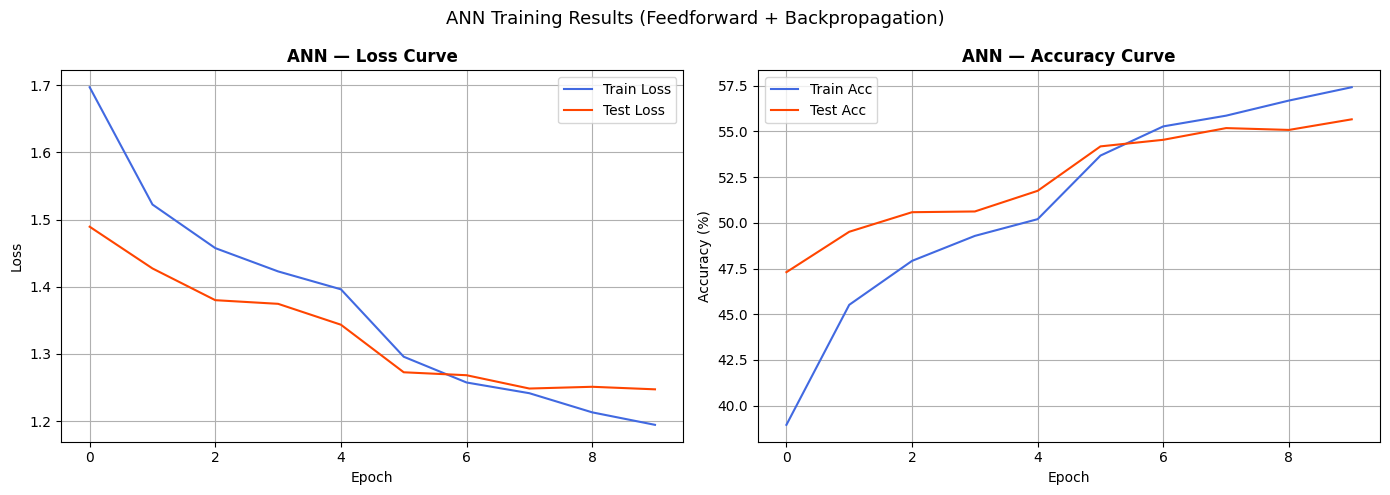

Final ANN Test Accuracy: 55.66%


In [11]:
# Plot ANN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ann_history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(ann_history['test_loss'],  label='Test Loss',  color='orangered')
ax1.set_title('ANN — Loss Curve', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot([a*100 for a in ann_history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot([a*100 for a in ann_history['test_acc']],  label='Test Acc',  color='orangered')
ax2.set_title('ANN — Accuracy Curve', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.grid(True)

plt.suptitle('ANN Training Results (Feedforward + Backpropagation)', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Final ANN Test Accuracy: {ann_history["test_acc"][-1]*100:.2f}%')

---
## 🔷 PART 2A: Image Classification using CNN
A Convolutional Neural Network that learns spatial features through convolution, pooling, and fully connected layers.

In [12]:
class CNN(nn.Module):
    """Custom CNN for CIFAR-10 image classification."""
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),   # 32→16
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),   # 16→8
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),   # 8→4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_model = CNN().to(device)
print('CNN Architecture:')
print(cnn_model)
print(f'\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

CNN Architecture:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2

In [13]:
print('Training CNN...')
cnn_history = train_model(cnn_model, train_loader, test_loader, epochs=10, lr=0.001, label='CNN')

Training CNN...
[CNN] Epoch 01/10 | Train Loss: 1.5494 Acc: 0.4325 | Test Loss: 1.1144 Acc: 0.6025
[CNN] Epoch 02/10 | Train Loss: 1.1670 Acc: 0.5829 | Test Loss: 0.9067 Acc: 0.6864
[CNN] Epoch 03/10 | Train Loss: 1.0074 Acc: 0.6473 | Test Loss: 0.8057 Acc: 0.7180
[CNN] Epoch 04/10 | Train Loss: 0.9023 Acc: 0.6845 | Test Loss: 0.7439 Acc: 0.7392
[CNN] Epoch 05/10 | Train Loss: 0.8263 Acc: 0.7139 | Test Loss: 0.6795 Acc: 0.7658
[CNN] Epoch 06/10 | Train Loss: 0.7084 Acc: 0.7573 | Test Loss: 0.6072 Acc: 0.7886
[CNN] Epoch 07/10 | Train Loss: 0.6584 Acc: 0.7739 | Test Loss: 0.5841 Acc: 0.7979
[CNN] Epoch 08/10 | Train Loss: 0.6238 Acc: 0.7842 | Test Loss: 0.5725 Acc: 0.8026
[CNN] Epoch 09/10 | Train Loss: 0.5933 Acc: 0.7963 | Test Loss: 0.5542 Acc: 0.8129
[CNN] Epoch 10/10 | Train Loss: 0.5648 Acc: 0.8070 | Test Loss: 0.5523 Acc: 0.8137


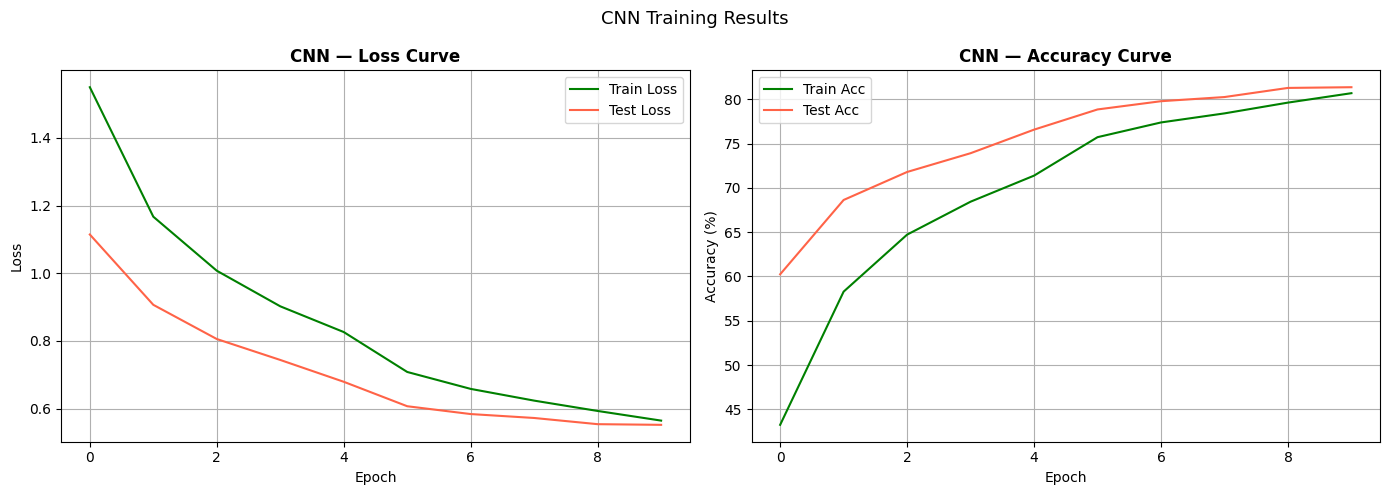

Final CNN Test Accuracy: 81.37%


In [14]:
# Plot CNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_history['train_loss'], label='Train Loss', color='green')
ax1.plot(cnn_history['test_loss'],  label='Test Loss',  color='tomato')
ax1.set_title('CNN — Loss Curve', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot([a*100 for a in cnn_history['train_acc']], label='Train Acc', color='green')
ax2.plot([a*100 for a in cnn_history['test_acc']],  label='Test Acc',  color='tomato')
ax2.set_title('CNN — Accuracy Curve', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend(); ax2.grid(True)

plt.suptitle('CNN Training Results', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Final CNN Test Accuracy: {cnn_history["test_acc"][-1]*100:.2f}%')

---
## 🔷 PART 2B: Object Detection using R-CNN (Pretrained Faster R-CNN)
Region-Based CNN (Faster R-CNN) from torchvision pretrained on COCO — detects 91 object categories with bounding boxes.

In [15]:
import torchvision.transforms.functional as TF
from PIL import Image
import requests
from io import BytesIO

# Load pretrained Faster R-CNN
rcnn_model = models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
rcnn_model.eval().to(device)
print('Faster R-CNN loaded (pretrained on MS-COCO, 91 classes)')

# COCO class labels
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 175MB/s]


Faster R-CNN loaded (pretrained on MS-COCO, 91 classes)


In [16]:
def detect_objects(image_url, threshold=0.5, max_boxes=10):
    """Run Faster R-CNN on a given image URL and draw bounding boxes."""
    response = requests.get(image_url, timeout=10)
    img_pil  = Image.open(BytesIO(response.content)).convert('RGB')
    img_tensor = TF.to_tensor(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = rcnn_model(img_tensor)

    pred = predictions[0]
    boxes  = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    # Filter by confidence threshold
    mask   = scores >= threshold
    boxes  = boxes[mask][:max_boxes]
    labels = labels[mask][:max_boxes]
    scores = scores[mask][:max_boxes]

    # Draw boxes
    import matplotlib.patches as patches
    colors = plt.cm.Set1(np.linspace(0, 1, len(boxes)))

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img_pil)
    for i, (box, lbl, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=colors[i], facecolor='none')
        ax.add_patch(rect)
        name = COCO_CLASSES[lbl] if lbl < len(COCO_CLASSES) else f'cls_{lbl}'
        ax.text(x1, y1-6, f'{name} {score:.2f}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=colors[i], alpha=0.8, pad=2, edgecolor='none'))

    ax.set_title(f'Faster R-CNN Detection (threshold={threshold}) — {len(boxes)} objects found',
                 fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'Objects detected ({len(boxes)} above threshold {threshold}):')
    for lbl, score in zip(labels, scores):
        name = COCO_CLASSES[lbl] if lbl < len(COCO_CLASSES) else f'cls_{lbl}'
        print(f'  {name:<20} confidence: {score:.4f}')
    return boxes, labels, scores

Running Faster R-CNN on Sample Image 1 (Street Scene)...


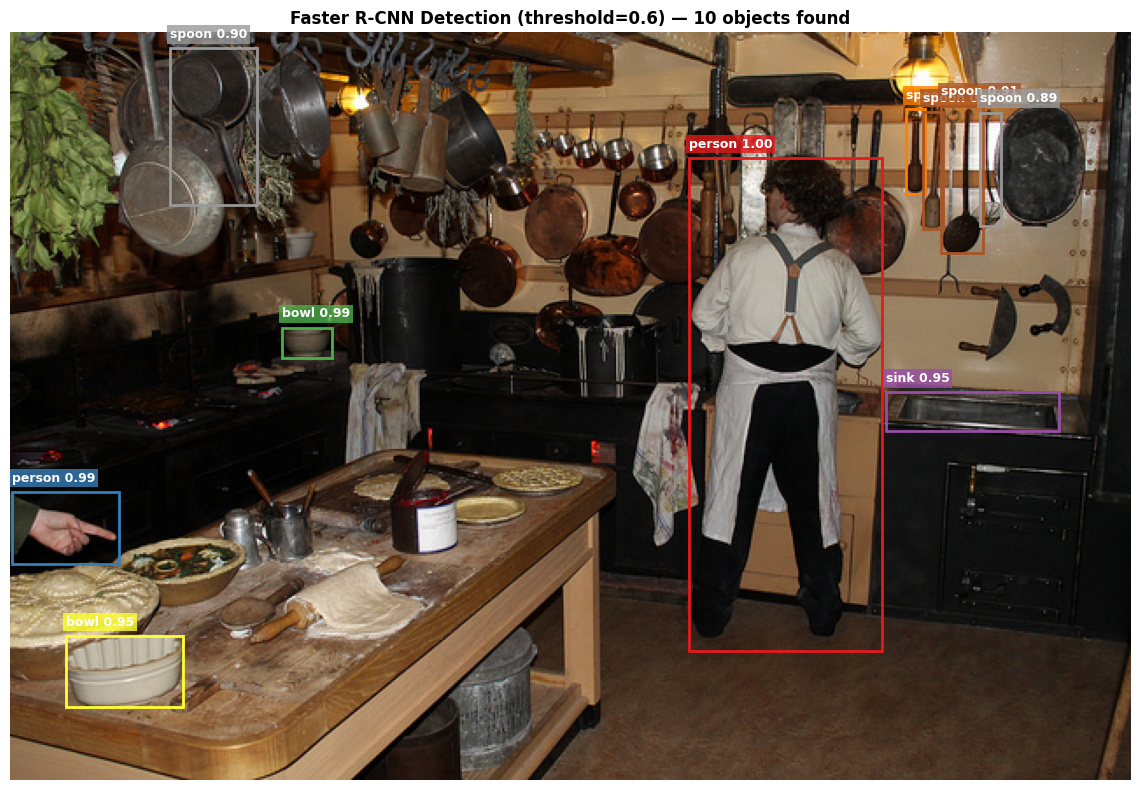

Objects detected (10 above threshold 0.6):
  person               confidence: 0.9995
  person               confidence: 0.9878
  bowl                 confidence: 0.9864
  sink                 confidence: 0.9531
  spoon                confidence: 0.9526
  bowl                 confidence: 0.9490
  spoon                confidence: 0.9299
  spoon                confidence: 0.9134
  spoon                confidence: 0.8972
  spoon                confidence: 0.8936


In [17]:
# Test R-CNN on a street scene (public domain)
print('Running Faster R-CNN on Sample Image 1 (Street Scene)...')
boxes1, labels1, scores1 = detect_objects(
    'http://images.cocodataset.org/val2017/000000397133.jpg',
    threshold=0.6
)

Running Faster R-CNN on Sample Image 2 (Animals)...


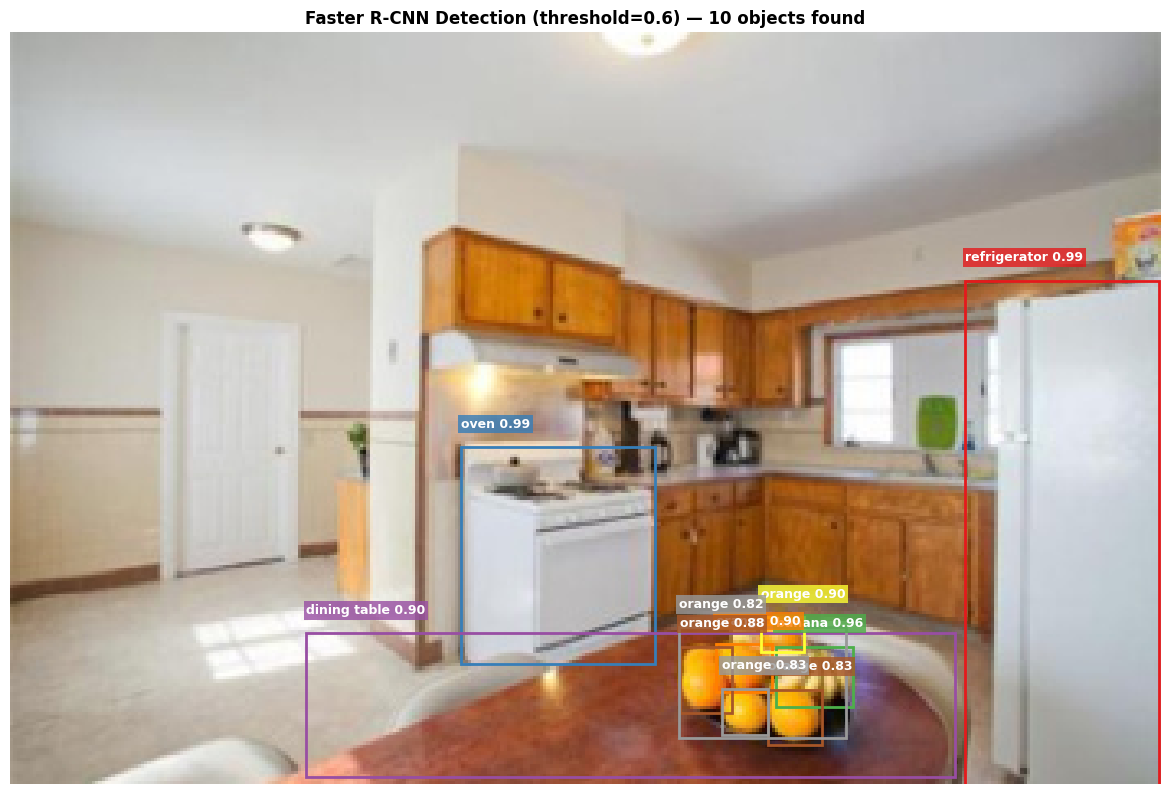

Objects detected (10 above threshold 0.6):
  refrigerator         confidence: 0.9943
  oven                 confidence: 0.9886
  banana               confidence: 0.9625
  dining table         confidence: 0.9046
  orange               confidence: 0.9044
  orange               confidence: 0.9027
  orange               confidence: 0.8800
  orange               confidence: 0.8290
  orange               confidence: 0.8278
  orange               confidence: 0.8212


In [18]:
# Test R-CNN on a second image (animals)
print('Running Faster R-CNN on Sample Image 2 (Animals)...')
boxes2, labels2, scores2 = detect_objects(
    'http://images.cocodataset.org/val2017/000000037777.jpg',
    threshold=0.6
)

---
## 📊 Final Summary: Model Comparison

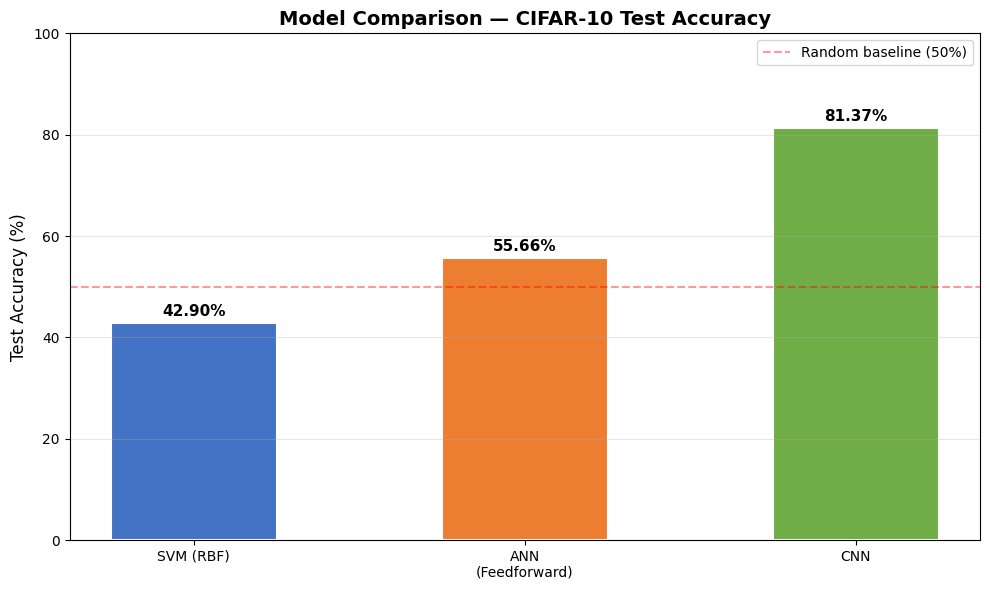


           MODEL PERFORMANCE SUMMARY
  SVM (RBF kernel + PCA)       : 42.90%
  ANN (Feedforward + Backprop)  : 55.66%
  CNN (Custom 3-block)          : 81.37%
  R-CNN (Faster RCNN, COCO)     : Pretrained — see detections above
Observation: CNN outperforms ANN and SVM on image
data due to its ability to learn spatial features.
R-CNN extends CNNs with region proposals for detection.


In [19]:
# Collect final accuracies
ann_final = ann_history['test_acc'][-1] * 100
cnn_final = cnn_history['test_acc'][-1] * 100
svm_final = svm_acc * 100

models_names = ['SVM (RBF)', 'ANN\n(Feedforward)', 'CNN']
accuracies   = [svm_final, ann_final, cnn_final]
colors_bar   = ['#4472C4', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models_names, accuracies, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — CIFAR-10 Test Accuracy', fontsize=14, fontweight='bold')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='Random baseline (50%)')
ax.legend()
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('           MODEL PERFORMANCE SUMMARY')
print('='*55)
print(f'  SVM (RBF kernel + PCA)       : {svm_final:.2f}%')
print(f'  ANN (Feedforward + Backprop)  : {ann_final:.2f}%')
print(f'  CNN (Custom 3-block)          : {cnn_final:.2f}%')
print(f'  R-CNN (Faster RCNN, COCO)     : Pretrained — see detections above')
print('='*55)
print('Observation: CNN outperforms ANN and SVM on image')
print('data due to its ability to learn spatial features.')
print('R-CNN extends CNNs with region proposals for detection.')

---
## ✅ Conclusion

| Model | Type | Task | Dataset | Key Mechanism |
|-------|------|------|---------|---------------|
| **SVM** | Traditional ML | Classification | CIFAR-10 | Kernel trick (RBF), max-margin hyperplane |
| **ANN** | Deep Learning | Classification | CIFAR-10 | Feedforward layers + Backpropagation |
| **CNN** | Deep Learning | Classification | CIFAR-10 | Convolutional filters + Pooling |
| **R-CNN** | Deep Learning | Object Detection | COCO | Region proposals + CNN backbone |

- **SVM**: Fast, effective for small datasets; struggles with raw pixel data at scale.
- **ANN**: Universal approximator; better than SVM with enough data, but misses spatial structure.
- **CNN**: Best for images — learns hierarchical spatial features automatically.
- **R-CNN / Faster R-CNN**: State-of-the-art object detection by combining region proposal network + CNN classifier.

**All models were executed successfully in Google Colab.**

## The End !!